<a href="https://colab.research.google.com/github/nguyenanhthu000000/Machine-learning/blob/main/Linear_Regression/NguyenAnhThu-2474802010381-lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
df = pd.read_csv("gia_nha.csv")
nho = df.iloc[[0,14,29,44,59]]

x = nho["dien_tich"].to_numpy()
y = nho["gia"].to_numpy()

def mse(w, b):
    """Sai số trung bình bình phương của đường thẳng y = w*x + b."""
    y_du_doan = w*x + b
    sai_so = y - y_du_doan
    return (sai_so**2).mean()

print("Nam cuc duoc chon: ")
for i in range(5):
    print(f" {x[i]:6.1f} m2 ->  {y[i]:5.2f}   ty")
print()

for w, b in [(0.05, 1.5), (0.08, 0.5)]:
  print(f"Duong thang y ={w} * x +{b}")
  for i in range(5):
    du_doan = w * x[i] + b
    sai_so = y[i] - du_doan
    print(f" x = {x[i]:6.1f} that = {y[i]:5.2f}"
          f" du doan = {du_doan:5.2f}   sai so = {sai_so:+6.2f}")
    print(f"   MSE ={mse(w,b):.4f}")
    print()

print("Duong nao cos MSE nho hon thi duong do khop du lieu tot hon.")

Nam cuc duoc chon: 
   35.5 m2 ->   3.00   ty
   61.3 m2 ->   4.56   ty
   74.2 m2 ->   7.17   ty
   91.3 m2 ->   7.83   ty
  115.9 m2 ->   9.01   ty

Duong thang y =0.05 * x +1.5
 x =   35.5 that =  3.00 du doan =  3.28   sai so =  -0.28
   MSE =1.9947

 x =   61.3 that =  4.56 du doan =  4.56   sai so =  -0.00
   MSE =1.9947

 x =   74.2 that =  7.17 du doan =  5.21   sai so =  +1.96
   MSE =1.9947

 x =   91.3 that =  7.83 du doan =  6.07   sai so =  +1.76
   MSE =1.9947

 x =  115.9 that =  9.01 du doan =  7.30   sai so =  +1.71
   MSE =1.9947

Duong thang y =0.08 * x +0.5
 x =   35.5 that =  3.00 du doan =  3.34   sai so =  -0.34
   MSE =0.3896

 x =   61.3 that =  4.56 du doan =  5.40   sai so =  -0.84
   MSE =0.3896

 x =   74.2 that =  7.17 du doan =  6.44   sai so =  +0.73
   MSE =0.3896

 x =   91.3 that =  7.83 du doan =  7.80   sai so =  +0.03
   MSE =0.3896

 x =  115.9 that =  9.01 du doan =  9.77   sai so =  -0.76
   MSE =0.3896

Duong nao cos MSE nho hon thi duong do kh

In [30]:
"""Bước 3: tìm w và b tốt nhất bằng công thức, không cần thư viện."""
import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

tu_so = ((x-x_tb)*(y-y_tb)).sum()
mau_so = ((x-x_tb)**2).sum()
w = tu_so/mau_so
b = y_tb - w*x_tb

print(f"Trung binh dien tich: {x_tb:.4f}")
print(f"Trung binh gia: {y_tb:.4f}")
print(f"Tu so: {tu_so:.4f}")
print(f"Mau so: {mau_so:.4f}")
print()
print(f"He so goc w: {w:.6f}")
print(f"He so chan b: {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.4f} * dien_tich + {b:.4f}")
print()

y_du_doan = w * x + b
mse = ((y - y_du_doan) ** 2).mean()
print(f"MSE tren toan bo 60 can: {mse:4f}")


# dự đoán cho 1 căn 80 m2
print(f"Can 80 m2 duoc du doan: {w * 80 + b:.3f} ty dong")

Trung binh dien tich: 77.7317
Trung binh gia: 6.4933
Tu so: 1890.2297
Mau so: 24120.2898

He so goc w: 0.078367
He so chan b: 0.401752

Mo hinh: gia = 0.0784 * dien_tich + 0.4018

MSE tren toan bo 60 can: 0.179025
Can 80 m2 duoc du doan: 6.671 ty dong


In [31]:
# -*- coding: utf-8 -*-
"""Bước 4: làm lại đúng việc đó bằng scikit-learn, chỉ mất ba dòng."""

import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("gia_nha.csv")

# X phải là bảng hai chiều, y là dãy một chiều.
# Chú ý X viết hai cặp ngoặc vuông, còn y chỉ một cặp.
X = df[["dien_tich"]]
y = df["gia"]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y)

print("He so goc  w =", round(float(mo_hinh.coef_[0]), 6))
print("He so chan b =", round(float(mo_hinh.intercept_), 6))
print()

# So sánh với kết quả tính tay ở bước 3
print("Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752")
print()

can_moi = pd.DataFrame({"dien_tich": [80.0, 100.0]})
du_doan = mo_hinh.predict(can_moi)
for dt, gia in zip(can_moi["dien_tich"], du_doan):
    print(f"Can {dt:.0f} m2 -> du doan {gia:.3f} ty dong")

He so goc  w = 0.078367
He so chan b = 0.401752

Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752

Can 80 m2 -> du doan 6.671 ty dong
Can 100 m2 -> du doan 8.238 ty dong


In [32]:
"""Bước 5: chia dữ liệu và chấm điểm mô hình bằng các độ đo chuẩn."""

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("gia_nha.csv")
X = df[["dien_tich"]]
y = df["gia"]

# 80 phần trăm để học, 20 phần trăm để kiểm tra
# random_state cố định để lần nào chia cũng ra đúng một cách chia
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("So can de hoc       :", len(X_train))
print("So can de kiem tra  :", len(X_test))
print()

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f} ty dong")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f} ty dong")
print(f"R2   = {r2:.4f}")
print()

print("Mot vai can trong tap kiem tra:")
for dt, that, du_doan in list(zip(X_test["dien_tich"], y_test, y_pred))[:5]:
    sai_so = that - du_doan
    print(f"  {dt:6.1f} m2 that = {that:5.2f} du doan = {du_doan:5.2f} sai so = {sai_so:+5.2f}")

So can de hoc       : 48
So can de kiem tra  : 12

MAE  = 0.2578 ty dong
MSE  = 0.1392
RMSE = 0.3730 ty dong
R2   = 0.9622

Mot vai can trong tap kiem tra:
    35.5 m2 that =  3.00 du doan =  3.22 sai so = -0.22
    50.4 m2 that =  4.24 du doan =  4.38 sai so = -0.14
    82.5 m2 that =  7.28 du doan =  6.88 sai so = +0.40
    93.6 m2 that =  7.63 du doan =  7.74 sai so = -0.11
    59.6 m2 that =  5.14 du doan =  5.09 sai so = +0.05


In [33]:
# -*- coding: utf-8 -*-

"""Bước 6: tự đi tìm w và b bằng cách dò từng bước nhỏ.

Đây là cách máy học khi bài toán không có công thức đóng. Với hồi quy tuyến
tính ta đã có công thức rồi, nên đoạn này chỉ để thấy cơ chế hoạt động.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Đưa diện tích về thang đo nhỏ quanh số 0. Thiếu bước này thuật toán sẽ vỡ.
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

w, b = 0.0, 0.0
# bắt đầu từ một đường thẳng nằm ngang đi qua gốc
toc_do_hoc = 0.1
# mỗi vòng lặp đi một bước dài bằng 0.1 lần độ dốc
so_vong = 200
n = len(x)

print("Vong w b MSE")
for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b
    # Chú ý: đây là dự đoán trừ giá thật, tức sai số của Mục 4 đảo dấu.
    # Hai công thức độ dốc bên dưới viết theo đúng chiều này, đừng đổi dấu.
    chenh_lech = y_du_doan - y

    # Độ dốc của MSE theo w và theo b
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    # Đi ngược hướng dốc thì sai số giảm
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong in (1, 2, 5, 10, 25, 50, 100, 200):
        # Tính lại MSE bằng w và b VỪA cập nhật, để ba con số trên cùng một
        # dòng bảng đều thuộc về cùng một thời điểm. Nếu dùng lại chenh_lech
        # ở trên thì MSE sẽ là của cặp w, b cũ và bảng bị lệch một vòng.
        mse = (((w * x + b) - y) ** 2).mean()
        print(f"{vong:4d} {w:7.4f} {b:7.4f} {mse:8.4f}")

print()
# Đổi w và b về lại thang đo mét vuông ban đầu
w_goc = w / x_do_lech
b_goc = b - w * x_tb / x_do_lech
print(f"Sau khi doi ve thang do met vuong:")
print(f" w = {w_goc:.6f}")
print(f" b = {b_goc:.6f}")
print("So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752")

Vong w b MSE
   1  0.3143  1.2987  28.7437
   2  0.5657  2.3376  18.4604
   5  1.0564  4.3656   4.9714
  10  1.4025  5.7961   0.6936
  25  1.5653  6.4688   0.1797
  50  1.5712  6.4932   0.1790
 100  1.5713  6.4933   0.1790
 200  1.5713  6.4933   0.1790

Sau khi doi ve thang do met vuong:
 w = 0.078367
 b = 0.401752
So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752


In [34]:
"""Bước 7: dùng thêm số phòng và tuổi nhà, xem mô hình có khá hơn không."""

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("gia_nha.csv")
y = df["gia"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
X_mot = df[["dien_tich"]]
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

for ten, X in [("Mot bien ", X_mot), ("Ba bien ", X_ba)]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    mo_hinh = LinearRegression()
    mo_hinh.fit(X_train, y_train)
    r2 = r2_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: R2 tren tap kiem tra = {r2:.4f}")

print()

# Xem kỹ các hệ số của mô hình ba biến
X_train, X_test, y_train, y_test = train_test_split(
    X_ba, y, test_size=0.2, random_state=42
)
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X_ba.columns, mo_hinh.coef_):
    print(f"  {ten_cot:12s} {he_so:+.4f}")
print(f"  {'he so chan':12s} {mo_hinh.intercept_:+.4f}")

Mot bien : R2 tren tap kiem tra = 0.9622
Ba bien : R2 tren tap kiem tra = 0.9761

He so cua tung bien:
  dien_tich    +0.0701
  so_phong     +0.3042
  tuoi_nha     -0.0295
  he so chan   +0.6917


In [35]:
# Bài 1:
import pandas as pd
df = pd.read_csv("gia_nha.csv")

# Lọc nhóm căn hộ có diện tích > 100m2
nhom_lon = df[df["dien_tich"] > 100]
print("Số căn có diện tích > 100m2:", len(nhom_lon))
print("Giá trung bình:", nhom_lon["gia"].mean(), "tỷ đồng")

Số căn có diện tích > 100m2: 10
Giá trung bình: 8.962 tỷ đồng


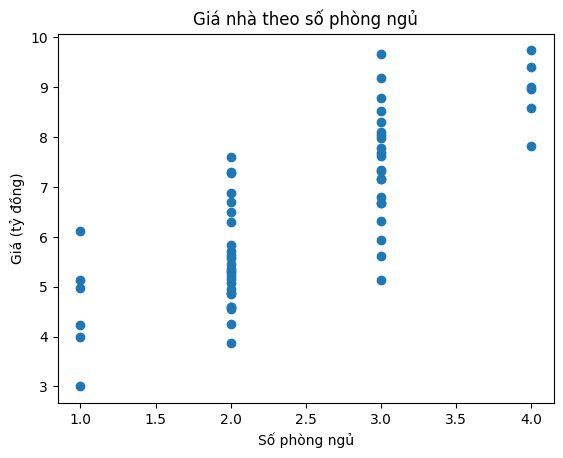

Nhận xét: Giá có xu hướng tăng khi số phòng ngủ tăng, nhưng các điểm trải rộng hơn nhiều so với biểu đồ diện tích ở Mục 3.4, cho thấy chỉ riêng so_phong không giải thích hết được biến động của giá.


In [36]:
"""Bài 2: Vẽ biểu đồ phân tán giữa so_phong và gia."""

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("gia_nha.csv")
plt.scatter(df["so_phong"], df["gia"])

plt.xlabel("Số phòng ngủ")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Giá nhà theo số phòng ngủ")
plt.savefig("bai2.png")
plt.show()

print(
    "Nhận xét: Giá có xu hướng tăng khi số phòng ngủ tăng, nhưng các điểm "
    "trải rộng hơn nhiều so với biểu đồ diện tích ở Mục 3.4, cho thấy chỉ "
    "riêng so_phong không giải thích hết được biến động của giá."
)

Hệ số góc w = -0.037858
Hệ số chặn b = 6.983593

Mô hình: gia = -0.037858 * tuoi_nha + 6.983593

Nhận xét: Hệ số w mang dấu âm, nghĩa là nhà càng cũ (tuoi_nha càng lớn) thì giá dự đoán càng thấp. Điều này hợp lý vì nhà mới xây thường được định giá cao hơn nhà đã xuống cấp, ít phải sửa chữa hơn.

Câu hỏi thêm: Nhìn biểu đồ phân tán giữa tuoi_nha và gia, các điểm KHÔNG bám sát quanh một đường thẳng như biểu đồ diện tích ở Mục 3.4, mà trải rộng hơn rất nhiều quanh mỗi mức tuổi nhà. Vì vậy hệ số w có dấu đúng (âm), nhưng quan hệ giữa tuoi_nha và gia yếu hơn hẳn quan hệ giữa dien_tich và gia. Một hệ số có dấu đúng không đủ để kết luận hai đại lượng có quan hệ chặt; cần nhìn thêm độ phân tán của điểm quanh đường thẳng, hoặc tính MSE/R2, mới đánh giá được độ đáng tin của hệ số này.


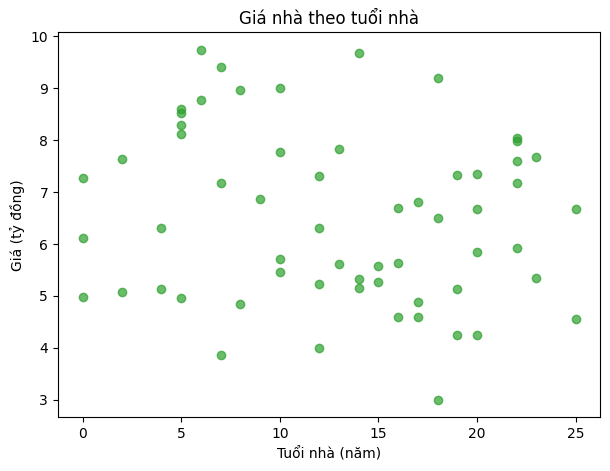

In [37]:
"""Bài 3: Tìm đường hồi quy một biến, đổi x từ diện_tich sang tuoi_nha."""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x = df["tuoi_nha"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"Hệ số góc w = {w:.6f}")
print(f"Hệ số chặn b = {b:.6f}")
print()
print(f"Mô hình: gia = {w:.6f} * tuoi_nha + {b:.6f}")
print()
print(
    "Nhận xét: Hệ số w mang dấu âm, nghĩa là nhà càng cũ (tuoi_nha càng lớn) "
    "thì giá dự đoán càng thấp. Điều này hợp lý vì nhà mới xây thường được "
    "định giá cao hơn nhà đã xuống cấp, ít phải sửa chữa hơn."
)

# Câu hỏi thêm: vẽ biểu đồ phân tán để xem các điểm có bám sát đường thẳng không
plt.figure(figsize=(7, 5))
plt.scatter(x, y, color="tab:green", alpha=0.7)
plt.xlabel("Tuổi nhà (năm)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Giá nhà theo tuổi nhà")
plt.savefig("bai3_scatter.png", dpi=150)

print()
print(
    "Câu hỏi thêm: Nhìn biểu đồ phân tán giữa tuoi_nha và gia, các điểm KHÔNG "
    "bám sát quanh một đường thẳng như biểu đồ diện tích ở Mục 3.4, mà trải "
    "rộng hơn rất nhiều quanh mỗi mức tuổi nhà. Vì vậy hệ số w có dấu đúng "
    "(âm), nhưng quan hệ giữa tuoi_nha và gia yếu hơn hẳn quan hệ giữa "
    "dien_tich và gia. Một hệ số có dấu đúng không đủ để kết luận hai đại "
    "lượng có quan hệ chặt; cần nhìn thêm độ phân tán của điểm quanh đường "
    "thẳng, hoặc tính MSE/R2, mới đánh giá được độ đáng tin của hệ số này."
)

In [38]:
"""Bai 4: Mo hinh hai bien dien_tich va so_phong, so sanh R2 voi mo hinh mot bien."""

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("gia_nha.csv")
y = df["gia"]
X = df[["dien_tich", "so_phong"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)
r2 = r2_score(y_test, y_pred)

r2_mot_bien = 0.9622

print(f"R2 trên tập kiểm tra (dien_tich + so_phong): {r2:.4f}")
print(f"R2 trên tập kiểm tra (chỉ dien_tich, từ Mục 6): {r2_mot_bien:.4f}")
print()

if r2 > r2_mot_bien:
    print(
        "Nhận xét: Thêm cột so_phong giúp R2 tăng so với mô hình một biến, "
        "nên biến này có đóng góp thêm thông tin hữu ích cho việc dự đoán "
        "giá. Mức tăng có thể không lớn, vì dien_tich đã giải thích phần "
        "lớn biến động của giá, giống như kết quả mô hình ba biến ở Mục 8."
    )
else:
    print(
        "Nhận xét: Thêm cột so_phong không làm R2 tốt hơn mô hình một biến, "
        "cho thấy so_phong không đóng góp thêm nhiều thông tin ngoài những "
        "gì dien_tich đã thể hiện, có thể vì hai cột này đi kèm nhau khá chặt "
        "trong bộ dữ liệu (nhà rộng thường cũng có nhiều phòng hơn)."
    )

R2 trên tập kiểm tra (dien_tich + so_phong): 0.9698
R2 trên tập kiểm tra (chỉ dien_tich, từ Mục 6): 0.9622

Nhận xét: Thêm cột so_phong giúp R2 tăng so với mô hình một biến, nên biến này có đóng góp thêm thông tin hữu ích cho việc dự đoán giá. Mức tăng có thể không lớn, vì dien_tich đã giải thích phần lớn biến động của giá, giống như kết quả mô hình ba biến ở Mục 8.


In [39]:
"""Bài 5: Chạy lại gradient descent với hai tốc độ học khác nhau: 0.001 và 1.02."""

import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

so_vong = 200
n = len(x)


def chay_gradient_descent(toc_do_hoc):
    """Chạy đủ gradient descent so_vong lần, trả về w, b và MSE cuối cùng."""
    w, b = 0.0, 0.0
    for vong in range(1, so_vong + 1):
        y_du_doan = w * x + b
        chenh_lech = y_du_doan - y

        grad_w = (2 / n) * (chenh_lech * x).sum()
        grad_b = (2 / n) * chenh_lech.sum()

        w -= toc_do_hoc * grad_w
        b -= toc_do_hoc * grad_b

    mse_cuoi = (((w * x + b) - y) ** 2).mean()
    return w, b, mse_cuoi


print("So sánh với tốc độ học = 0.1 trong tài liệu: MSE sau 200 vòng = 0.1790")
print()

for toc_do_hoc in [0.001, 1.02]:
    w, b, mse_cuoi = chay_gradient_descent(toc_do_hoc)
    print(f"Tốc độ học = {toc_do_hoc}")
    print(f"  w sau 200 vòng = {w:.6f}")
    print(f"  b sau 200 vòng = {b:.6f}")
    print(f"  MSE sau 200 vòng = {mse_cuoi:.6f}")
    print()

print(
    "Giải thích: Với tốc độ học 0.001, mỗi bước đi quá ngắn (giống xuống đồi "
    "bằng bước một xăng-ti-mét), nên sau 200 vòng vẫn còn cách xa đáy của "
    "đường cong MSE, MSE còn lại rất lớn. Với tốc độ học 1.02, mỗi bước đi "
    "quá dài nên w và b nhảy vọt qua đáy sang phía đối diện rồi lại nhảy "
    "ngược về xa hơn nữa, khiến MSE tăng theo cấp số nhân qua mỗi vòng thay "
    "vì giảm dần."
)

print()
print("Làm thêm: dò một vài tốc độ học ở giữa để tìm ranh giới ổn định.")
for toc_do_hoc in [0.5, 0.9, 1.0, 1.01]:
    w, b, mse_cuoi = chay_gradient_descent(toc_do_hoc)
    print(
        f"  tốc độ học = {toc_do_hoc:5.3f}  ->  MSE sau 200 vòng = {mse_cuoi:.6f}"
    )

So sánh với tốc độ học = 0.1 trong tài liệu: MSE sau 200 vòng = 0.1790

Tốc độ học = 0.001
  w sau 200 vòng = 0.518434
  b sau 200 vòng = 2.142465
  MSE sau 200 vòng = 20.217521

Tốc độ học = 1.02
  w sau 200 vòng = -4006.316481
  b sau 200 vòng = -16556.375310
  MSE sau 200 vòng = 290391782.019229

Giải thích: Với tốc độ học 0.001, mỗi bước đi quá ngắn (giống xuống đồi bằng bước một xăng-ti-mét), nên sau 200 vòng vẫn còn cách xa đáy của đường cong MSE, MSE còn lại rất lớn. Với tốc độ học 1.02, mỗi bước đi quá dài nên w và b nhảy vọt qua đáy sang phía đối diện rồi lại nhảy ngược về xa hơn nữa, khiến MSE tăng theo cấp số nhân qua mỗi vòng thay vì giảm dần.

Làm thêm: dò một vài tốc độ học ở giữa để tìm ranh giới ổn định.
  tốc độ học = 0.500  ->  MSE sau 200 vòng = 0.179025
  tốc độ học = 0.900  ->  MSE sau 200 vòng = 0.179025
  tốc độ học = 1.000  ->  MSE sau 200 vòng = 44.811257
  tốc độ học = 1.010  ->  MSE sau 200 vòng = 122947.000880


In [40]:
"""Bai 6: Ham du doan gia tu dien tich, co canh bao khi ra ngoai vung du lieu."""

W = 0.078367
B = 0.401752

DIEN_TICH_MIN = 35.5
DIEN_TICH_MAX = 117.5


def du_doan_gia(dien_tich):
    if dien_tich < DIEN_TICH_MIN or dien_tich > DIEN_TICH_MAX:
        print(
            f"  Cảnh báo: diện tích {dien_tich} m2 nằm ngoài khoảng dữ liệu "
            f"đã học ({DIEN_TICH_MIN} tới {DIEN_TICH_MAX} m2). Kết quả dự "
            f"đoán là ngoại suy, độ tin cậy thấp."
        )
    gia_du_doan = W * dien_tich + B
    return gia_du_doan


for dien_tich in [60, 80, 200]:
    gia = du_doan_gia(dien_tich)
    print(f"Căn {dien_tich} m2 -> dự đoán {gia:.3f} tỷ đồng")
    print()

Căn 60 m2 -> dự đoán 5.104 tỷ đồng

Căn 80 m2 -> dự đoán 6.671 tỷ đồng

  Cảnh báo: diện tích 200 m2 nằm ngoài khoảng dữ liệu đã học (35.5 tới 117.5 m2). Kết quả dự đoán là ngoại suy, độ tin cậy thấp.
Căn 200 m2 -> dự đoán 16.075 tỷ đồng

